# Fed Interest Rate Changes & Financial Sector Stock Performance
## Exploratory Data Analysis

This notebook explores the raw data and engineered features before model training.

In [1]:
import os
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

DB_CONFIG = {
    'host':     os.getenv('DB_HOST', 'localhost'),
    'port':     os.getenv('DB_PORT', '5432'),
    'dbname':   os.getenv('DB_NAME', 'fed_rates_db'),
    'user':     os.getenv('DB_USER', 'postgres'),
    'password': os.getenv('DB_PASSWORD'),
}

def query(sql):
    with psycopg2.connect(**DB_CONFIG) as conn:
        return pd.read_sql(sql, conn)

print('Connected successfully.')

Connected successfully.


---
## 1. Federal Funds Rate History

In [2]:
fed = query('SELECT date, rate, change_bp FROM fed_rates ORDER BY date')
fed['date'] = pd.to_datetime(fed['date'])

print(f'Rows: {len(fed)}')
print(f'Date range: {fed.date.min().date()} → {fed.date.max().date()}')
fed.head()

Rows: 9572
Date range: 2000-01-02 → 2026-03-17


/var/folders/6s/2b_r6vds1tjczn64tgbp4r4r0000gn/T/ipykernel_51151/1561962806.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


,date,rate,change_bp
0,2000-01-02,3.99,0.0
1,2000-01-03,5.43,144.0
2,2000-01-04,5.38,-5.0
3,2000-01-05,5.41,3.0
4,2000-01-06,5.54,13.0


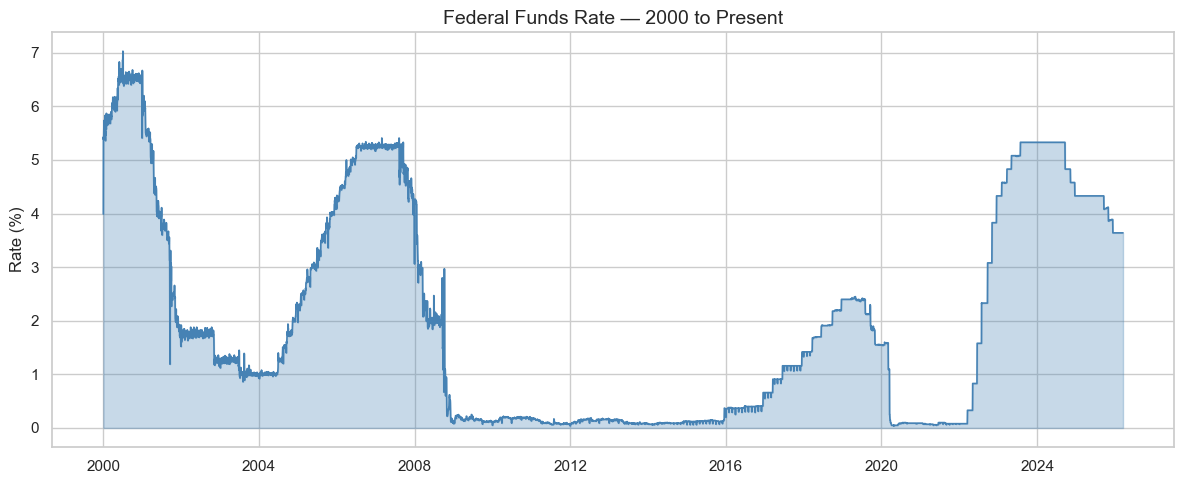

In [3]:
fig, ax = plt.subplots()
ax.fill_between(fed['date'], fed['rate'], alpha=0.3, color='steelblue')
ax.plot(fed['date'], fed['rate'], color='steelblue', linewidth=1.2)
ax.set_title('Federal Funds Rate — 2000 to Present', fontsize=14)
ax.set_ylabel('Rate (%)')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

---
## 2. FOMC Meetings

In [4]:
fomc = query('SELECT date, rate, change_bp FROM fomc_meetings ORDER BY date')
fomc['date'] = pd.to_datetime(fomc['date'])
fomc['direction'] = fomc['change_bp'].apply(lambda x: 'Hike' if x > 0 else ('Cut' if x < 0 else 'Hold'))

print(f'Total FOMC meetings: {len(fomc)}')
print(fomc['direction'].value_counts())
fomc.tail(10)

Total FOMC meetings: 31
direction
Hike    20
Cut     11
Name: count, dtype: int64


/var/folders/6s/2b_r6vds1tjczn64tgbp4r4r0000gn/T/ipykernel_51151/1561962806.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


,date,rate,change_bp,direction
21,2023-02-02,4.75,25.0,Hike
22,2023-03-23,5.00,25.0,Hike
23,2023-05-04,5.25,25.0,Hike
24,2023-07-27,5.50,25.0,Hike
25,2024-09-19,5.00,-50.0,Cut
26,2024-11-08,4.75,-25.0,Cut
27,2024-12-19,4.50,-25.0,Cut
28,2025-09-18,4.25,-25.0,Cut
29,2025-10-30,4.00,-25.0,Cut
30,2025-12-11,3.75,-25.0,Cut


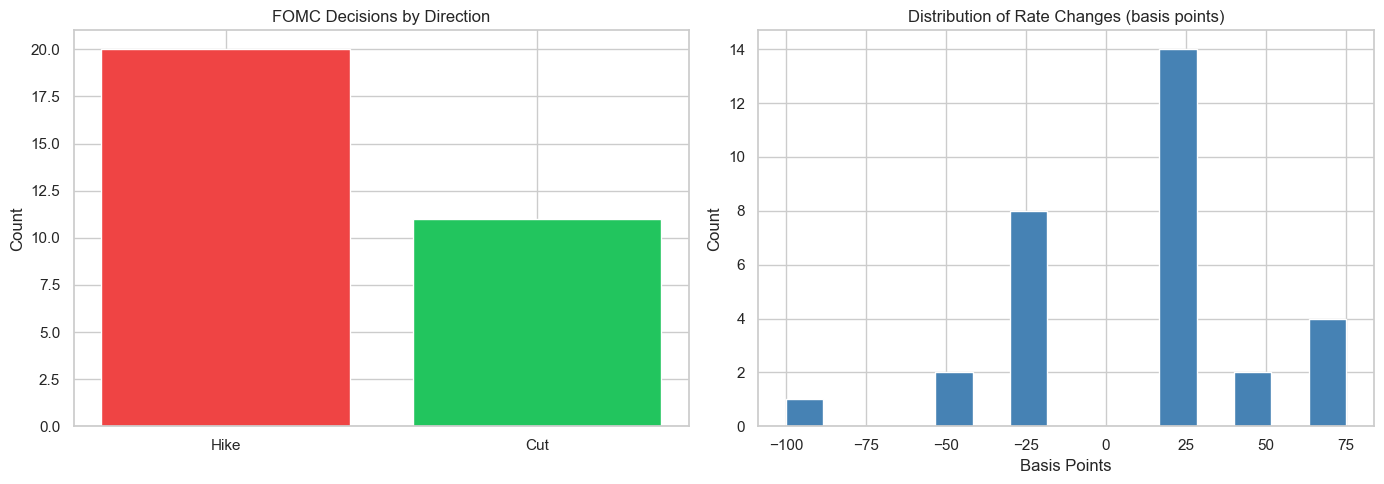

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Direction breakdown
counts = fomc['direction'].value_counts()
colors = {'Hike': '#EF4444', 'Cut': '#22C55E', 'Hold': '#94A3B8'}
axes[0].bar(counts.index, counts.values, color=[colors[d] for d in counts.index])
axes[0].set_title('FOMC Decisions by Direction')
axes[0].set_ylabel('Count')

# Distribution of change sizes
axes[1].hist(fomc['change_bp'], bins=15, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution of Rate Changes (basis points)')
axes[1].set_xlabel('Basis Points')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

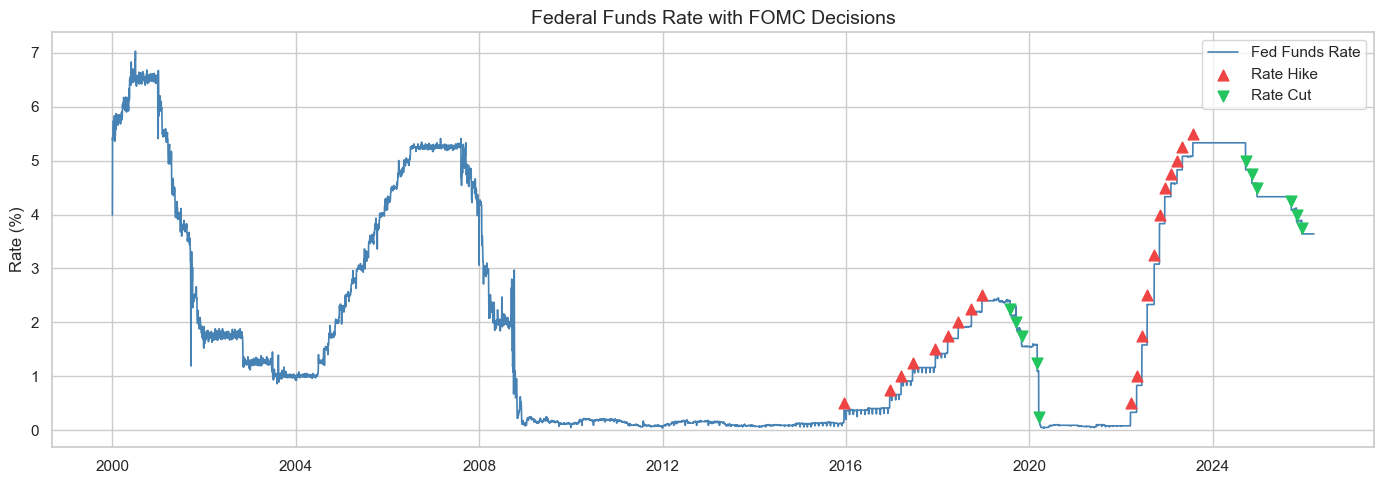

In [6]:
# Rate chart with FOMC meeting markers
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(fed['date'], fed['rate'], color='steelblue', linewidth=1.2, label='Fed Funds Rate')

hikes = fomc[fomc['direction'] == 'Hike']
cuts  = fomc[fomc['direction'] == 'Cut']

ax.scatter(hikes['date'], hikes['rate'], color='#EF4444', zorder=5, label='Rate Hike', s=60, marker='^')
ax.scatter(cuts['date'],  cuts['rate'],  color='#22C55E', zorder=5, label='Rate Cut',  s=60, marker='v')

ax.set_title('Federal Funds Rate with FOMC Decisions', fontsize=14)
ax.set_ylabel('Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Stock Price History

In [7]:
stocks = query('SELECT date, ticker, close FROM stock_prices ORDER BY date')
stocks['date'] = pd.to_datetime(stocks['date'])

print(f'Total rows: {len(stocks)}')
print(stocks.groupby('ticker')['date'].agg(['min', 'max', 'count']))

Total rows: 46137
              min        max  count
ticker                             
BAC    2000-01-03 2026-03-18   6591
C      2000-01-03 2026-03-18   6591
GS     2000-01-03 2026-03-18   6591
JPM    2000-01-03 2026-03-18   6591
MS     2000-01-03 2026-03-18   6591
SPY    2000-01-03 2026-03-18   6591
WFC    2000-01-03 2026-03-18   6591


/var/folders/6s/2b_r6vds1tjczn64tgbp4r4r0000gn/T/ipykernel_51151/1561962806.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


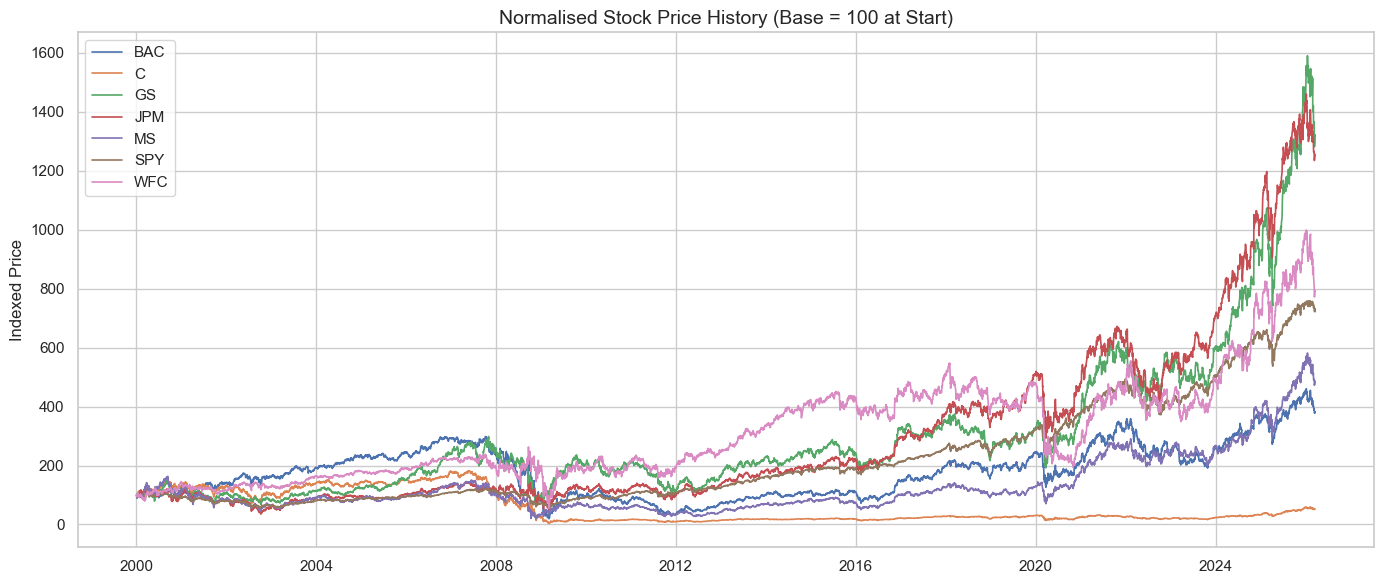

In [8]:
# Normalised price history (all starting at 100)
wide = stocks.pivot(index='date', columns='ticker', values='close')
normalized = wide.div(wide.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 6))
for ticker in normalized.columns:
    ax.plot(normalized.index, normalized[ticker], label=ticker, linewidth=1.2)

ax.set_title('Normalised Stock Price History (Base = 100 at Start)', fontsize=14)
ax.set_ylabel('Indexed Price')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

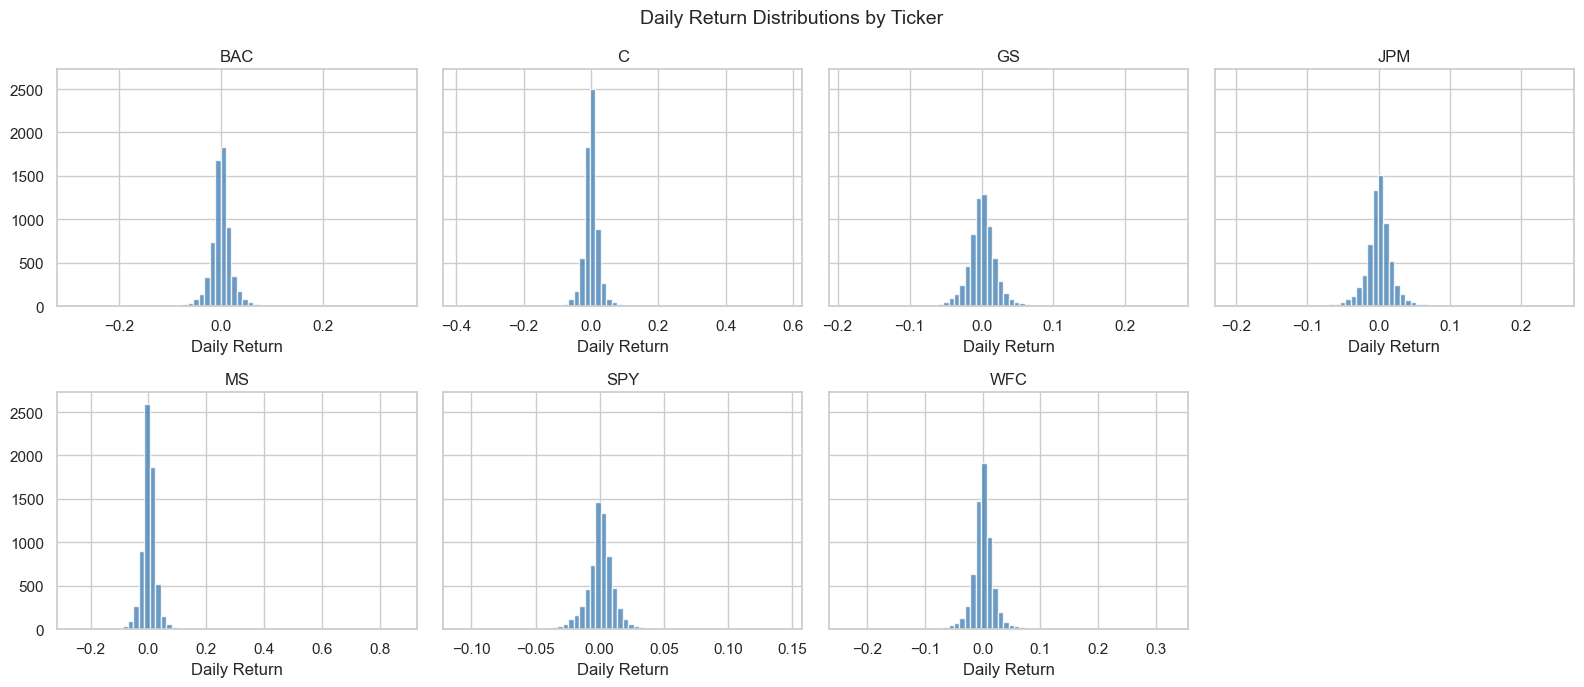

In [9]:
# Daily return distributions
daily_returns = wide.pct_change().dropna()

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=True)
axes = axes.flatten()

for i, ticker in enumerate(daily_returns.columns):
    axes[i].hist(daily_returns[ticker], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(ticker)
    axes[i].set_xlabel('Daily Return')

# Hide unused subplot
axes[-1].set_visible(False)

fig.suptitle('Daily Return Distributions by Ticker', fontsize=14)
plt.tight_layout()
plt.show()

---
## 4. Engineered Features

In [10]:
features = query('SELECT * FROM features ORDER BY fomc_date, ticker')
features['fomc_date'] = pd.to_datetime(features['fomc_date'])

print(f'Feature rows: {len(features)}')
print(f'Tickers: {features.ticker.unique()}')
print(f'\nClass balance:')
print(features['outperformed'].value_counts())
features.head()

Feature rows: 186
Tickers: ['BAC' 'C' 'GS' 'JPM' 'MS' 'WFC']

Class balance:
outperformed
0    93
1    93
Name: count, dtype: int64


/var/folders/6s/2b_r6vds1tjczn64tgbp4r4r0000gn/T/ipykernel_51151/1561962806.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


,fomc_date,ticker,rate_before,change_bp,direction,abs_change_bp,rate_level_regime,pre_return_10d,pre_return_30d,pre_volatility_30d,pre_rel_return_10d,pre_rel_return_30d,stock_return_30d,spy_return_30d,outperformed
0,2015-12-16,BAC,0.15,25.0,hike,25.0,low,0.007376,0.036082,0.269384,0.009774,0.050158,-0.213515,-0.063585,0
1,2015-12-16,C,0.15,25.0,hike,25.0,low,-0.004434,-0.004800,0.253108,-0.002036,0.009276,-0.210901,-0.063585,0
2,2015-12-16,GS,0.15,25.0,hike,25.0,low,-0.021287,-0.020150,0.267389,-0.018889,-0.006074,-0.142635,-0.063585,0
3,2015-12-16,JPM,0.15,25.0,hike,25.0,low,0.013051,0.026602,0.235063,0.015449,0.040679,-0.122539,-0.063585,0
4,2015-12-16,MS,0.15,25.0,hike,25.0,low,-0.036686,0.009614,0.290941,-0.034288,0.023691,-0.230522,-0.063585,0


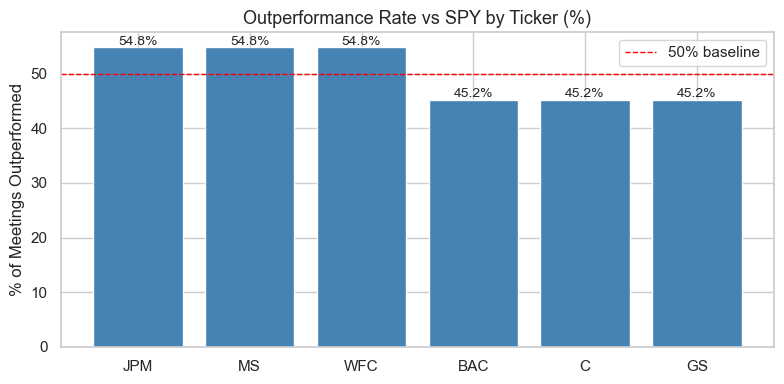

In [11]:
# Outperformance rate by ticker
win_rates = features.groupby('ticker')['outperformed'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(win_rates.index, win_rates.values * 100, color='steelblue', edgecolor='white')
ax.axhline(50, color='red', linestyle='--', linewidth=1, label='50% baseline')
ax.set_title('Outperformance Rate vs SPY by Ticker (%)', fontsize=13)
ax.set_ylabel('% of Meetings Outperformed')
ax.legend()
for bar, val in zip(bars, win_rates.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f'{val*100:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

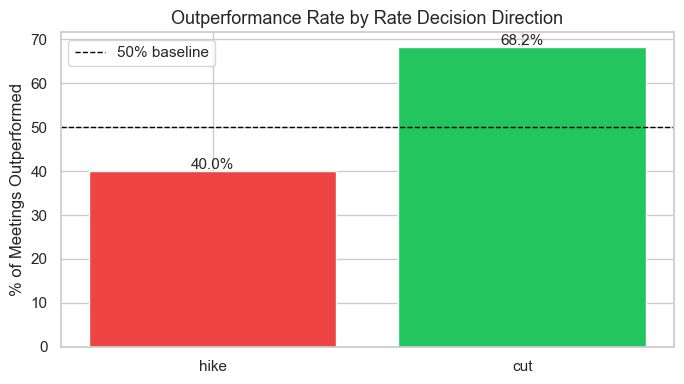

In [12]:
# Outperformance rate by rate direction
direction_perf = features.groupby('direction')['outperformed'].mean().reindex(['hike', 'cut', 'hold'])

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#EF4444', '#22C55E', '#94A3B8']
bars = ax.bar(direction_perf.index, direction_perf.values * 100, color=colors, edgecolor='white')
ax.axhline(50, color='black', linestyle='--', linewidth=1, label='50% baseline')
ax.set_title('Outperformance Rate by Rate Decision Direction', fontsize=13)
ax.set_ylabel('% of Meetings Outperformed')
ax.legend()
for bar, val in zip(bars, direction_perf.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f'{val*100:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

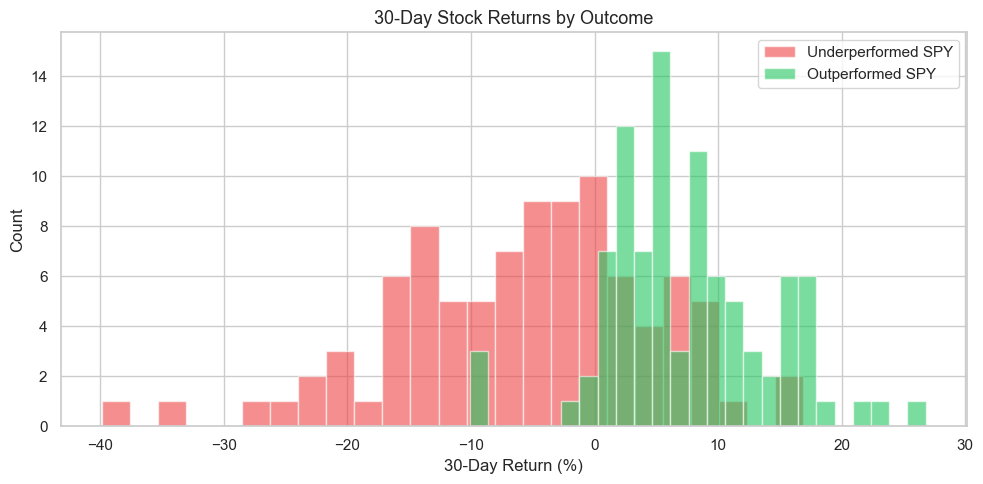

In [13]:
# 30-day return distributions: outperform vs underperform
fig, ax = plt.subplots(figsize=(10, 5))
for label, group in features.groupby('outperformed'):
    name = 'Outperformed SPY' if label == 1 else 'Underperformed SPY'
    color = '#22C55E' if label == 1 else '#EF4444'
    ax.hist(group['stock_return_30d'] * 100, bins=25, alpha=0.6, label=name, color=color, edgecolor='white')

ax.set_title('30-Day Stock Returns by Outcome', fontsize=13)
ax.set_xlabel('30-Day Return (%)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Feature Correlations

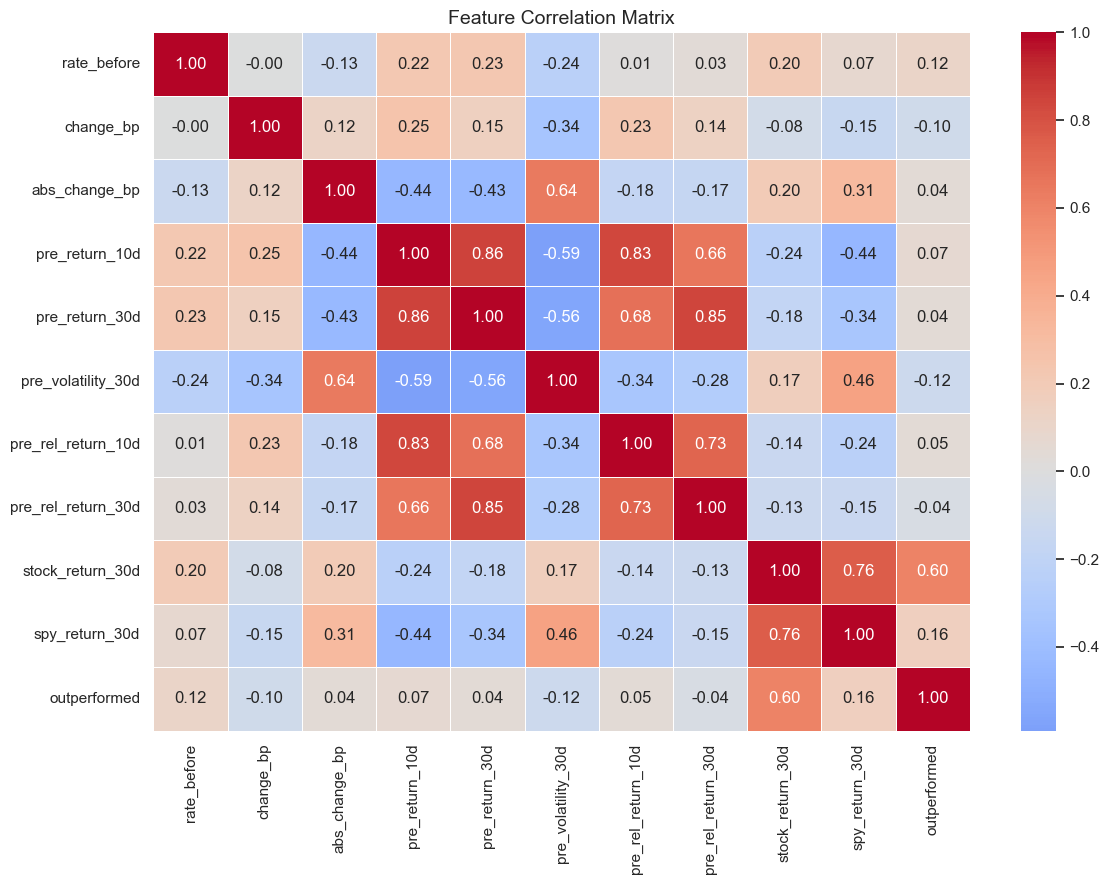

In [14]:
num_cols = [
    'rate_before', 'change_bp', 'abs_change_bp',
    'pre_return_10d', 'pre_return_30d', 'pre_volatility_30d',
    'pre_rel_return_10d', 'pre_rel_return_30d',
    'stock_return_30d', 'spy_return_30d', 'outperformed'
]

corr = features[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax
)
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

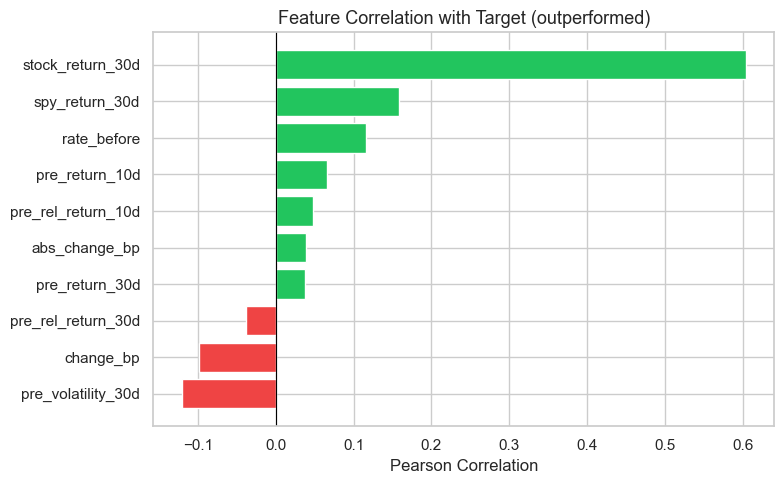

In [15]:
# Correlation of each feature with the target
target_corr = corr['outperformed'].drop('outperformed').sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#EF4444' if v < 0 else '#22C55E' for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Target (outperformed)', fontsize=13)
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()